In [1]:
# Hide all code cells when presenting
from IPython.display import HTML, display
display(HTML("""
<style>
    div.input, div.jp-InputArea, .jp-Cell-inputWrapper { display: none !important; }
    div.output_area pre { font-size: 13px; }
    .jp-RenderedHTMLCommon h1 { color: #1a1a2e; border-bottom: 3px solid #2C5F8A; padding-bottom: 10px; }
    .jp-RenderedHTMLCommon h2 { color: #2C5F8A; margin-top: 2em; }
    .jp-RenderedHTMLCommon h3 { color: #444; }
    .jp-RenderedHTMLCommon p, .jp-RenderedHTMLCommon li { font-size: 15px; line-height: 1.6; color: #333; }
    .jp-RenderedHTMLCommon blockquote { border-left: 4px solid #2C5F8A; padding-left: 16px; color: #555; }
</style>
"""))

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
from matplotlib.patches import FancyBboxPatch
from matplotlib.ticker import FuncFormatter

# Professional style setup
plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'axes.edgecolor': '#CCCCCC',
    'axes.linewidth': 0.8,
    'axes.grid': True,
    'grid.color': '#E8E8E8',
    'grid.linewidth': 0.5,
    'grid.alpha': 0.7,
    'font.family': 'sans-serif',
    'font.size': 12,
    'axes.titlesize': 18,
    'axes.titleweight': 'bold',
    'axes.titlepad': 20,
    'axes.labelsize': 13,
    'axes.labelpad': 10,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'legend.framealpha': 0.9,
    'legend.edgecolor': '#CCCCCC',
    'figure.dpi': 150,
    'savefig.dpi': 150,
})

# Proficiency color palette
PROF_COLORS = {
    'Lower Emergent': '#DC143C',
    'Higher Emergent': '#FF8C00',
    'Developing': '#FFD700',
    'Transitioning': '#9ACD32',
    'Grade Level': '#228B22',
}
PROF_ORDER = ['Lower Emergent', 'Higher Emergent', 'Developing', 'Transitioning', 'Grade Level']
PROF_SHORT = {'Lower Emergent': 'LE', 'Higher Emergent': 'HE', 'Developing': 'Dev', 'Transitioning': 'Trans', 'Grade Level': 'GL'}

# Non-proficiency palette
PAL = dict(primary='#2C5F8A', secondary='#E07A3A', accent='#5DAE8B', warning='#C94C4C', neutral='#7B8A9E')

def clean_axes(ax):
    """Remove top/right spines, style remaining ones."""
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    ax.tick_params(colors='#555555')
    ax.xaxis.label.set_color('#333333')
    ax.yaxis.label.set_color('#333333')
    ax.title.set_color('#222222')

print("Style loaded.")


Style loaded.


In [2]:
# ── Data Loading ──────────────────────────────────────────
profiles = pd.read_parquet('../dashboard/data/school_profiles.parquet')
ordinal  = pd.read_parquet('../dashboard/data/school_ordinal.parquet')
metadata = pd.read_parquet('../dashboard/data/school_metadata.parquet')
chain    = pd.read_csv('../output/crla_chain_progress.ordinal_v2.csv')
ranking  = pd.read_csv('../output/priority_ranking_sef.Retention_2024-25_to_2025-26.csv')
robust   = pd.read_csv('../output/sensitivity_robustness.Retention_2024-25_to_2025-26.csv')
ktau     = pd.read_csv('../output/sensitivity_kendall_tau.Retention_2024-25_to_2025-26.csv')
jaccard  = pd.read_csv('../output/sensitivity_jaccard_top100.Retention_2024-25_to_2025-26.csv')

# National aggregates (School ID == -1)
national = ordinal[ordinal['School ID'] == -1].copy()
schools  = ordinal[ordinal['School ID'] != -1].copy()

TIMEPOINTS = ['BoSY 2024-25', 'EoSY 2024-25', 'BoSY 2025-26']
TP_SHORT = {'BoSY 2024-25': 'BoSY\n2024-25', 'EoSY 2024-25': 'EoSY\n2024-25', 'BoSY 2025-26': 'BoSY\n2025-26'}

print(f"Loaded: {len(profiles):,} profile rows | {len(schools):,} school-timepoint rows | {len(chain):,} chains | {len(ranking):,} ranked schools")


Loaded: 3,338,700 profile rows | 111,290 school-timepoint rows | 39,206 chains | 20,766 ranked schools


# CRLA Methodology Walkthrough
## How We Identify Schools That Need the Most Support

*Comprehensive Reading Literacy Assessment (CRLA) — Priority Ranking Framework*

---

## A. National Reading Landscape

> Where do Filipino elementary students stand in reading proficiency?


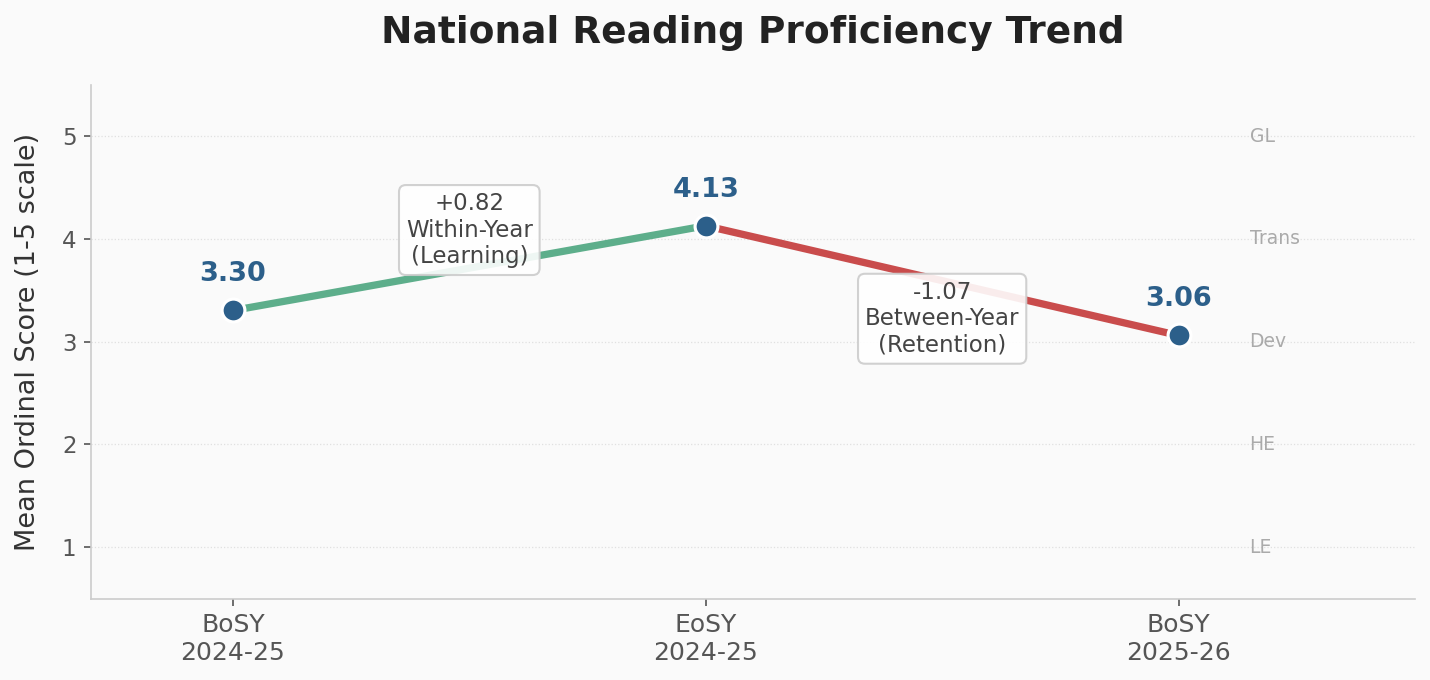

In [3]:
# ── Chart 1: National Mean Proficiency Trend (Slope Chart) ──
nat = national.set_index('timepoint_label').loc[TIMEPOINTS]

fig, ax = plt.subplots(figsize=(10, 5))

x_pos = [0, 1, 2]
means = nat['ordinal_overall'].values
colors_seg = [PAL['accent'], PAL['warning']]
labels_seg = ['Within-Year\n(Learning)', 'Between-Year\n(Retention)']

for i in range(2):
    ax.plot([x_pos[i], x_pos[i+1]], [means[i], means[i+1]],
            color=colors_seg[i], linewidth=3.5, zorder=3)
    mid_x = (x_pos[i] + x_pos[i+1]) / 2
    mid_y = (means[i] + means[i+1]) / 2
    delta = means[i+1] - means[i]
    sign = '+' if delta > 0 else ''
    ax.annotate(f'{sign}{delta:.2f}\n{labels_seg[i]}',
                xy=(mid_x, mid_y), fontsize=11, color='#444444',
                ha='center', va='bottom' if delta > 0 else 'top',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='#CCCCCC', alpha=0.9))

for i, (xp, m) in enumerate(zip(x_pos, means)):
    ax.scatter(xp, m, s=120, color=PAL['primary'], zorder=4, edgecolors='white', linewidth=1.5)
    ax.annotate(f'{m:.2f}', xy=(xp, m), xytext=(0, 14), textcoords='offset points',
                fontsize=13, fontweight='bold', ha='center', color=PAL['primary'])

# Reference bands
for level, y_val, lbl in [(1, 1, 'LE'), (2, 2, 'HE'), (3, 3, 'Dev'), (4, 4, 'Trans'), (5, 5, 'GL')]:
    ax.axhline(y=y_val, color='#E0E0E0', linewidth=0.6, linestyle=':', zorder=1)
    ax.text(2.15, y_val, lbl, fontsize=9, color='#AAAAAA', va='center')

ax.set_xticks(x_pos)
ax.set_xticklabels([TP_SHORT[t] for t in TIMEPOINTS], fontsize=12)
ax.set_ylabel('Mean Ordinal Score (1-5 scale)')
ax.set_ylim(0.5, 5.5)
ax.set_xlim(-0.3, 2.5)
ax.set_title('National Reading Proficiency Trend')
clean_axes(ax)
ax.grid(False)
plt.tight_layout(pad=2.0)
plt.show()


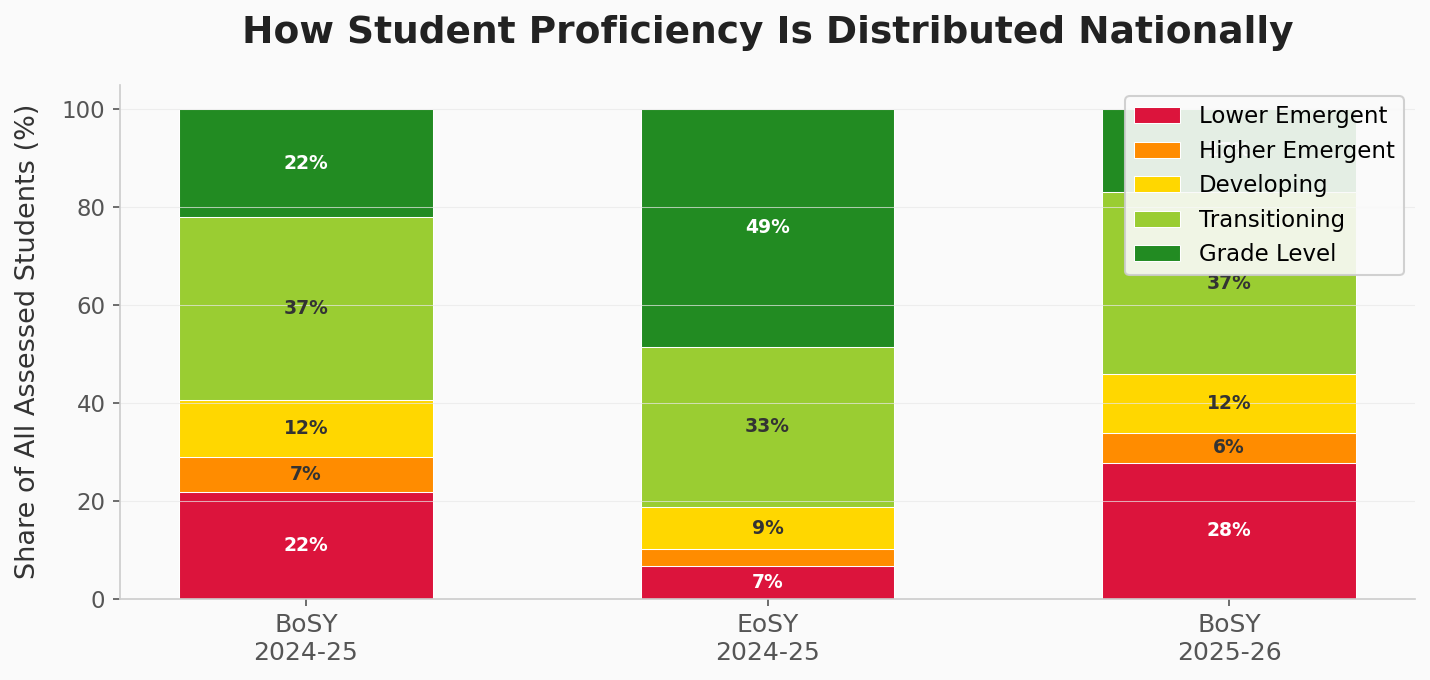

In [4]:
# ── Chart 2: National Proficiency Distribution (Stacked Bar) ──
# Aggregate raw counts across all schools per timepoint per profile
nat_dist = (profiles.groupby(['timepoint_label', 'profile'])['raw_count']
            .sum().reset_index())
nat_totals = nat_dist.groupby('timepoint_label')['raw_count'].sum().reset_index()
nat_totals.columns = ['timepoint_label', 'total']
nat_dist = nat_dist.merge(nat_totals)
nat_dist['pct'] = nat_dist['raw_count'] / nat_dist['total'] * 100

fig, ax = plt.subplots(figsize=(10, 5))
bar_width = 0.55
x_pos = np.arange(len(TIMEPOINTS))

bottoms = np.zeros(len(TIMEPOINTS))
for prof in PROF_ORDER:
    vals = []
    for tp in TIMEPOINTS:
        row = nat_dist[(nat_dist['timepoint_label'] == tp) & (nat_dist['profile'] == prof)]
        vals.append(row['pct'].values[0] if len(row) > 0 else 0)
    vals = np.array(vals)
    bars = ax.bar(x_pos, vals, bar_width, bottom=bottoms,
                  color=PROF_COLORS[prof], edgecolor='white', linewidth=0.5,
                  label=prof)
    # Label percentages inside bars if > 5%
    for i, (v, b) in enumerate(zip(vals, bottoms)):
        if v > 5:
            ax.text(x_pos[i], b + v/2, f'{v:.0f}%', ha='center', va='center',
                    fontsize=9, fontweight='bold', color='white' if prof in ['Lower Emergent', 'Grade Level'] else '#333')
    bottoms += vals

ax.set_xticks(x_pos)
ax.set_xticklabels([TP_SHORT[t] for t in TIMEPOINTS], fontsize=12)
ax.set_ylabel('Share of All Assessed Students (%)')
ax.set_ylim(0, 105)
ax.set_title('How Student Proficiency Is Distributed Nationally')
ax.legend(loc='upper right', frameon=True, ncol=1)
clean_axes(ax)
ax.grid(axis='x', visible=False)
plt.tight_layout(pad=2.0)
plt.show()


---
## B. Why the Mean Isn't Enough

> Two schools can have the same average reading score but very different student distributions.
> One school may have students clustered around "Developing," while another is split between "Lower Emergent" and "Grade Level."
> We need to look beyond averages.


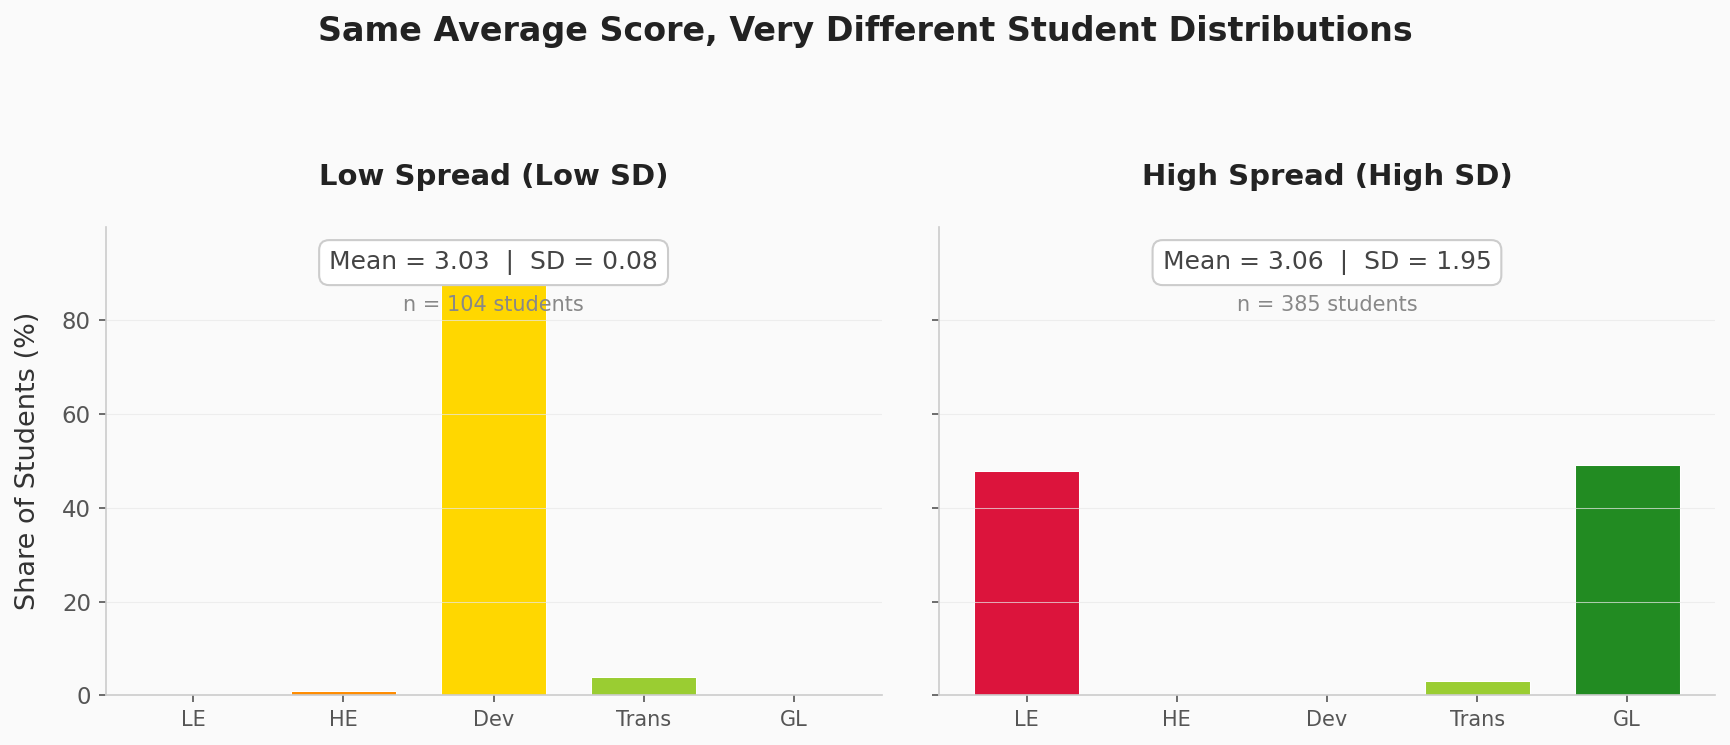

In [5]:
# ── Chart 3: Two Schools — Same Mean, Different Spread ──
bosy26 = schools[schools['timepoint_label'] == 'BoSY 2025-26'].copy()

# Merge SD from chain
bosy26 = bosy26.merge(
    chain[['School ID', 'sd_BoSY_2025-26']].rename(columns={'sd_BoSY_2025-26': 'sd'}),
    on='School ID', how='left'
)

# Find two schools with similar mean (~3.0) but different SD
target_mean = 3.0
candidates = bosy26[(bosy26['ordinal_overall'].between(2.9, 3.1)) & (bosy26['sd'].notna()) & (bosy26['total_assessed'] > 100)]

school_low = None
school_high = None

if len(candidates) > 0:
    low_sd = candidates.nsmallest(5, 'sd')
    high_sd = candidates.nlargest(5, 'sd')
    if len(low_sd) > 0:
        school_low = low_sd.iloc[0]
    if len(high_sd) > 0:
        school_high = high_sd.iloc[0]

# Fallback guard
if school_low is None or school_high is None:
    candidates_wider = bosy26[(bosy26['ordinal_overall'].between(2.7, 3.3)) & (bosy26['sd'].notna()) & (bosy26['total_assessed'] > 50)]
    if school_low is None and len(candidates_wider) > 0:
        school_low = candidates_wider.nsmallest(1, 'sd').iloc[0]
    if school_high is None and len(candidates_wider) > 0:
        school_high = candidates_wider.nlargest(1, 'sd').iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

for idx, (school, ax, label) in enumerate(zip(
    [school_low, school_high], axes, ['Low Spread (Low SD)', 'High Spread (High SD)'])):

    sid = int(school['School ID'])
    prof_data = profiles[(profiles['School ID'] == sid) &
                         (profiles['timepoint_label'] == 'BoSY 2025-26')].copy()
    # Aggregate across grade-lang groups to get school-level distribution
    prof_agg = prof_data.groupby('profile')['raw_count'].sum().reset_index()
    prof_total = prof_agg['raw_count'].sum()
    prof_agg['pct'] = prof_agg['raw_count'] / prof_total * 100
    prof_agg = prof_agg.set_index('profile').reindex(PROF_ORDER).fillna(0)

    bars = ax.bar(range(5), prof_agg['pct'].values,
                  color=[PROF_COLORS[p] for p in PROF_ORDER],
                  edgecolor='white', linewidth=0.5, width=0.7)

    ax.set_xticks(range(5))
    ax.set_xticklabels([PROF_SHORT[p] for p in PROF_ORDER], fontsize=10)
    ax.set_title(f'{label}', fontsize=14, fontweight='bold')
    ax.set_xlabel('')

    # Annotations
    mean_val = school['ordinal_overall']
    sd_val = school['sd']
    ax.text(0.5, 0.95, f'Mean = {mean_val:.2f}  |  SD = {sd_val:.2f}',
            transform=ax.transAxes, ha='center', va='top',
            fontsize=12, color='#444444',
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', edgecolor='#CCCCCC'))

    n_assessed = int(school['total_assessed'])
    ax.text(0.5, 0.82, f'n = {n_assessed:,} students', transform=ax.transAxes,
            ha='center', fontsize=10, color='#888888')

    clean_axes(ax)
    ax.grid(axis='x', visible=False)

axes[0].set_ylabel('Share of Students (%)')
fig.suptitle('Same Average Score, Very Different Student Distributions', fontsize=16, fontweight='bold', y=1.02, color='#222222')
plt.tight_layout(pad=2.0)
plt.show()

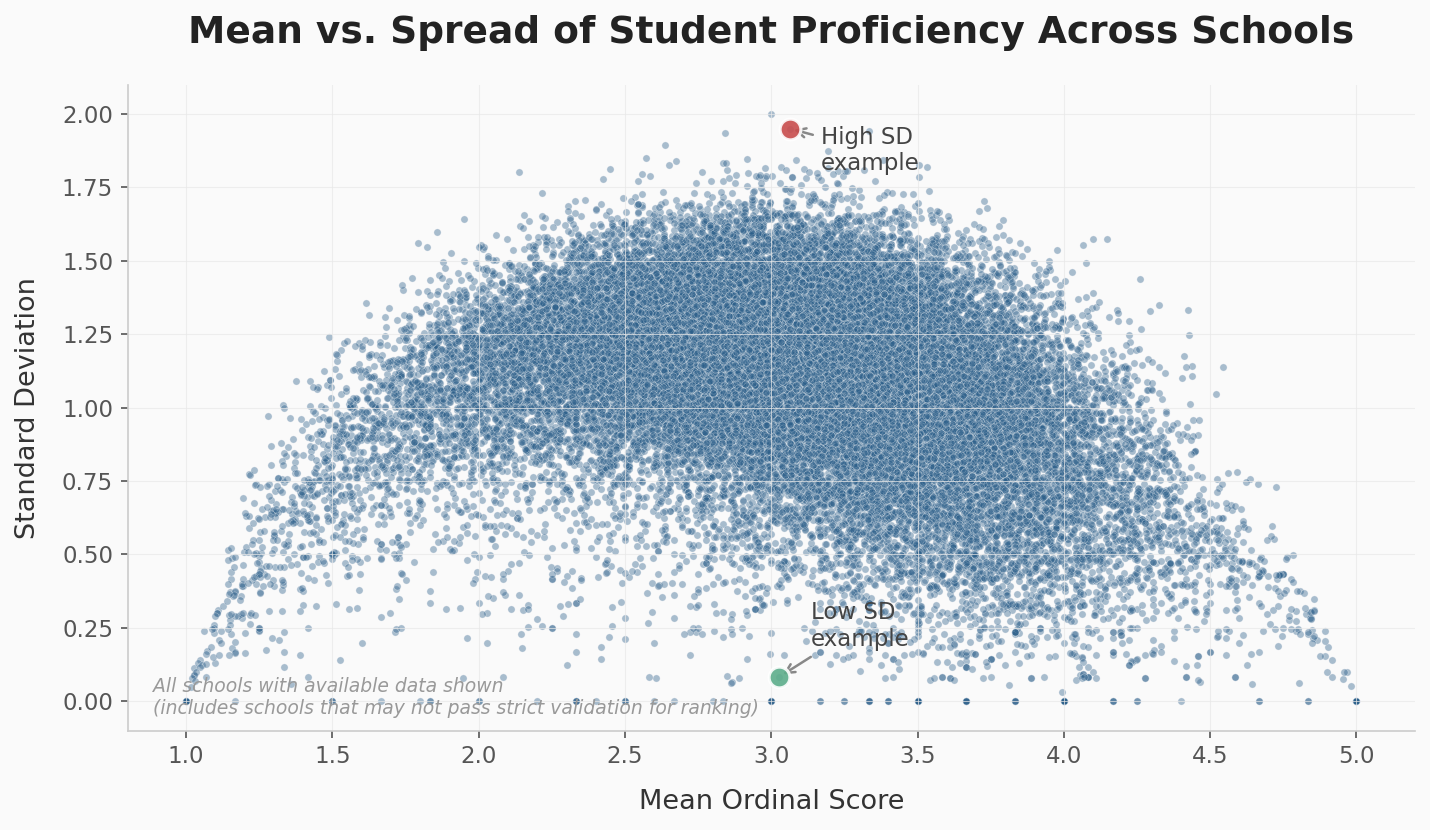

In [6]:
# ── Chart 4: Mean vs. SD Scatter — All Schools at BoSY 2025-26 ──
scatter_data = bosy26[bosy26['sd'].notna()].copy()

fig, ax = plt.subplots(figsize=(10, 6))

ax.scatter(scatter_data['ordinal_overall'], scatter_data['sd'],
           s=12, alpha=0.4, color=PAL['primary'], edgecolors='white', linewidth=0.3)

# Highlight the two example schools
if school_low is not None:
    ax.scatter(school_low['ordinal_overall'], school_low['sd'],
               s=100, alpha=0.9, color=PAL['accent'], edgecolors='white', linewidth=1.5, zorder=5)
    ax.annotate('Low SD\nexample', xy=(school_low['ordinal_overall'], school_low['sd']),
                xytext=(15, 15), textcoords='offset points', fontsize=11, color='#444444',
                arrowprops=dict(arrowstyle='->', color='#888888', lw=1.2))

if school_high is not None:
    ax.scatter(school_high['ordinal_overall'], school_high['sd'],
               s=100, alpha=0.9, color=PAL['warning'], edgecolors='white', linewidth=1.5, zorder=5)
    ax.annotate('High SD\nexample', xy=(school_high['ordinal_overall'], school_high['sd']),
                xytext=(15, -20), textcoords='offset points', fontsize=11, color='#444444',
                arrowprops=dict(arrowstyle='->', color='#888888', lw=1.2))

ax.set_xlabel('Mean Ordinal Score')
ax.set_ylabel('Standard Deviation')
ax.set_title('Mean vs. Spread of Student Proficiency Across Schools')
clean_axes(ax)

# Annotation note
ax.text(0.02, 0.02,
        'All schools with available data shown\n(includes schools that may not pass strict validation for ranking)',
        transform=ax.transAxes, fontsize=9, color='#999999', va='bottom', style='italic')

plt.tight_layout(pad=2.0)
plt.show()


---
## C. Three Measures of Reading Proficiency

> We capture three dimensions of each school's reading distribution:
> 1. **Mean** — the average proficiency level
> 2. **Standard Deviation (SD)** — how spread out students are
> 3. **Skewness** — whether the distribution leans toward higher or lower levels


Skewness panel verification: Positive skew mean = 3.00, Negative skew mean = 3.00


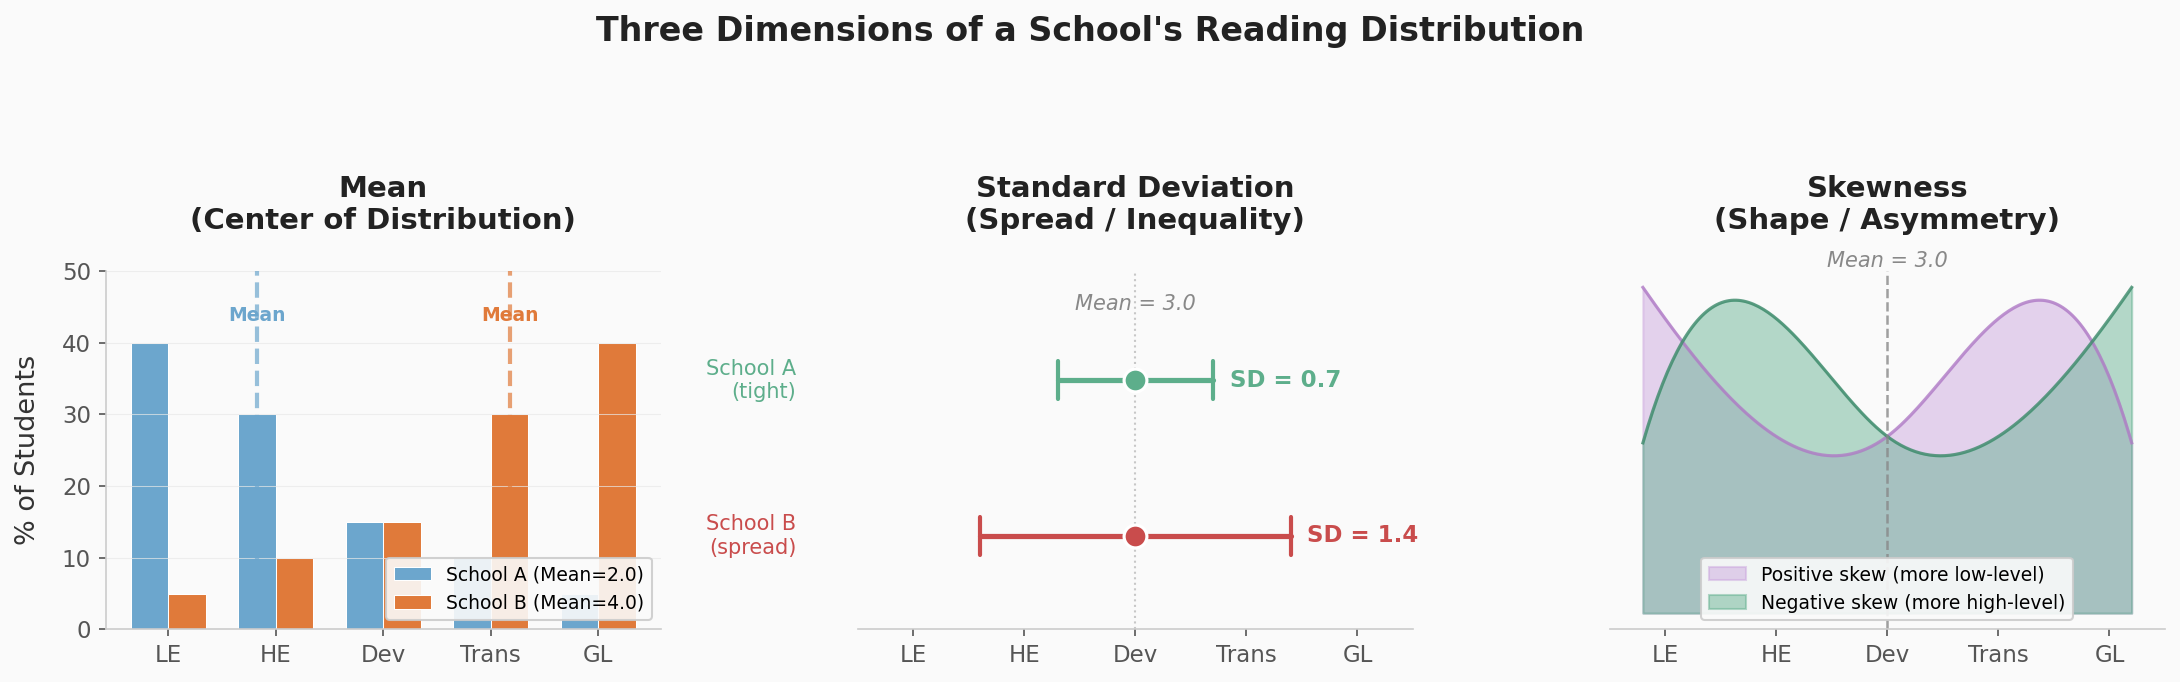

In [7]:
# ── Chart 5: Schematic — Mean, SD, Skewness ──
from scipy.interpolate import make_interp_spline

fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

levels = ['LE', 'HE', 'Dev', 'Trans', 'GL']
level_vals = [1, 2, 3, 4, 5]

# --- Panel 1: MEAN (keep paired bar, move legend) ---
ax = axes[0]
dist_low = [0.40, 0.30, 0.15, 0.10, 0.05]
dist_high = [0.05, 0.10, 0.15, 0.30, 0.40]

x = np.arange(5)
w = 0.35
ax.bar(x - w/2, [d*100 for d in dist_low], w, color='#6CA6CD', edgecolor='white', linewidth=0.5, label='School A (Mean=2.0)')
ax.bar(x + w/2, [d*100 for d in dist_high], w, color='#E07A3A', edgecolor='white', linewidth=0.5, label='School B (Mean=4.0)')

ax.axvline(x=1 - w/2, color='#6CA6CD', linewidth=2, linestyle='--', alpha=0.7)
ax.axvline(x=3 + w/2, color='#E07A3A', linewidth=2, linestyle='--', alpha=0.7)
ax.text(1 - w/2, 43, 'Mean', ha='center', fontsize=9, color='#6CA6CD', fontweight='bold')
ax.text(3 + w/2, 43, 'Mean', ha='center', fontsize=9, color='#E07A3A', fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels(levels)
ax.set_ylabel('% of Students')
ax.set_title('Mean\n(Center of Distribution)', fontsize=14)
ax.legend(fontsize=9, loc='lower right')
ax.set_ylim(0, 50)
clean_axes(ax)
ax.grid(axis='x', visible=False)

# --- Panel 2: SD (dot-and-whisker schematic) ---
ax = axes[1]

mean_val = 3.0
sd_low, sd_high = 0.7, 1.4

# School A: low SD
ax.plot([mean_val - sd_low, mean_val + sd_low], [1, 1], color=PAL['accent'], linewidth=2.5, solid_capstyle='round')
ax.scatter([mean_val], [1], s=120, color=PAL['accent'], edgecolors='white', linewidth=1.5, zorder=5)
for endpoint in [mean_val - sd_low, mean_val + sd_low]:
    ax.plot([endpoint, endpoint], [0.88, 1.12], color=PAL['accent'], linewidth=2, solid_capstyle='round')
ax.text(mean_val + sd_low + 0.15, 1, f'SD = {sd_low}', va='center', fontsize=11, color=PAL['accent'], fontweight='bold')

# School B: high SD
ax.plot([mean_val - sd_high, mean_val + sd_high], [0, 0], color=PAL['warning'], linewidth=2.5, solid_capstyle='round')
ax.scatter([mean_val], [0], s=120, color=PAL['warning'], edgecolors='white', linewidth=1.5, zorder=5)
for endpoint in [mean_val - sd_high, mean_val + sd_high]:
    ax.plot([endpoint, endpoint], [-0.12, 0.12], color=PAL['warning'], linewidth=2, solid_capstyle='round')
ax.text(mean_val + sd_high + 0.15, 0, f'SD = {sd_high}', va='center', fontsize=11, color=PAL['warning'], fontweight='bold')

# Labels
ax.text(-0.05, 1, 'School A\n(tight)', ha='right', va='center', fontsize=10, color=PAL['accent'])
ax.text(-0.05, 0, 'School B\n(spread)', ha='right', va='center', fontsize=10, color=PAL['warning'])

# Mean reference line
ax.axvline(x=mean_val, color='#BBBBBB', linewidth=1, linestyle=':', alpha=0.8, zorder=1)
ax.text(mean_val, 1.45, 'Mean = 3.0', ha='center', fontsize=10, color='#888888', style='italic')

ax.set_xlim(0.5, 5.5)
ax.set_ylim(-0.6, 1.7)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(levels)
ax.set_yticks([])
ax.set_title('Standard Deviation\n(Spread / Inequality)', fontsize=14)
clean_axes(ax)
ax.grid(False)
ax.spines['left'].set_visible(False)

# --- Panel 3: SKEWNESS (smoothed area curves, both mean = 3.0) ---
ax = axes[2]

# Positive skew: bulk at low levels, tail right. Mean = 3.0
# [0.25, 0.15, 0.15, 0.25, 0.20] -> 1*0.25+2*0.15+3*0.15+4*0.25+5*0.20 = 3.00
dist_pos = np.array([0.25, 0.15, 0.15, 0.25, 0.20]) * 100
# Negative skew: bulk at high levels, tail left. Mean = 3.0
# [0.20, 0.25, 0.15, 0.15, 0.25] -> 1*0.20+2*0.25+3*0.15+4*0.15+5*0.25 = 3.00
dist_neg = np.array([0.20, 0.25, 0.15, 0.15, 0.25]) * 100

# Verify means
ordinals = np.array([1, 2, 3, 4, 5])
mean_pos = np.sum(dist_pos / 100 * ordinals)
mean_neg = np.sum(dist_neg / 100 * ordinals)
print(f"Skewness panel verification: Positive skew mean = {mean_pos:.2f}, Negative skew mean = {mean_neg:.2f}")

# Smooth interpolation
x_pts = np.array([1, 2, 3, 4, 5])
x_fine = np.linspace(0.8, 5.2, 200)

spl_pos = make_interp_spline(x_pts, dist_pos, k=3)
spl_neg = make_interp_spline(x_pts, dist_neg, k=3)
y_pos = np.clip(spl_pos(x_fine), 0, None)
y_neg = np.clip(spl_neg(x_fine), 0, None)

ax.fill_between(x_fine, y_pos, alpha=0.45, color='#C9A0DC', label='Positive skew (more low-level)')
ax.plot(x_fine, y_pos, color='#B07CC6', linewidth=1.5, alpha=0.8)
ax.fill_between(x_fine, y_neg, alpha=0.45, color=PAL['accent'], label='Negative skew (more high-level)')
ax.plot(x_fine, y_neg, color='#3D8A6B', linewidth=1.5, alpha=0.8)

# Mean reference line
ax.axvline(x=3.0, color='#888888', linewidth=1.2, linestyle='--', alpha=0.8)
ax.text(3.0, max(y_pos.max(), y_neg.max()) * 1.05, 'Mean = 3.0', ha='center', va='bottom',
        fontsize=10, color='#888888', style='italic')

ax.set_xlim(0.5, 5.5)
ax.set_xticks([1, 2, 3, 4, 5])
ax.set_xticklabels(levels)
ax.set_yticks([])
ax.set_ylabel('')
ax.set_title('Skewness\n(Shape / Asymmetry)', fontsize=14)
ax.legend(fontsize=9, loc='lower center', frameon=True, ncol=1)
clean_axes(ax)
ax.grid(False)
ax.spines['left'].set_visible(False)

fig.suptitle("Three Dimensions of a School\'s Reading Distribution", fontsize=16, fontweight='bold', y=1.04, color='#222222')
plt.tight_layout(pad=2.0)
plt.show()


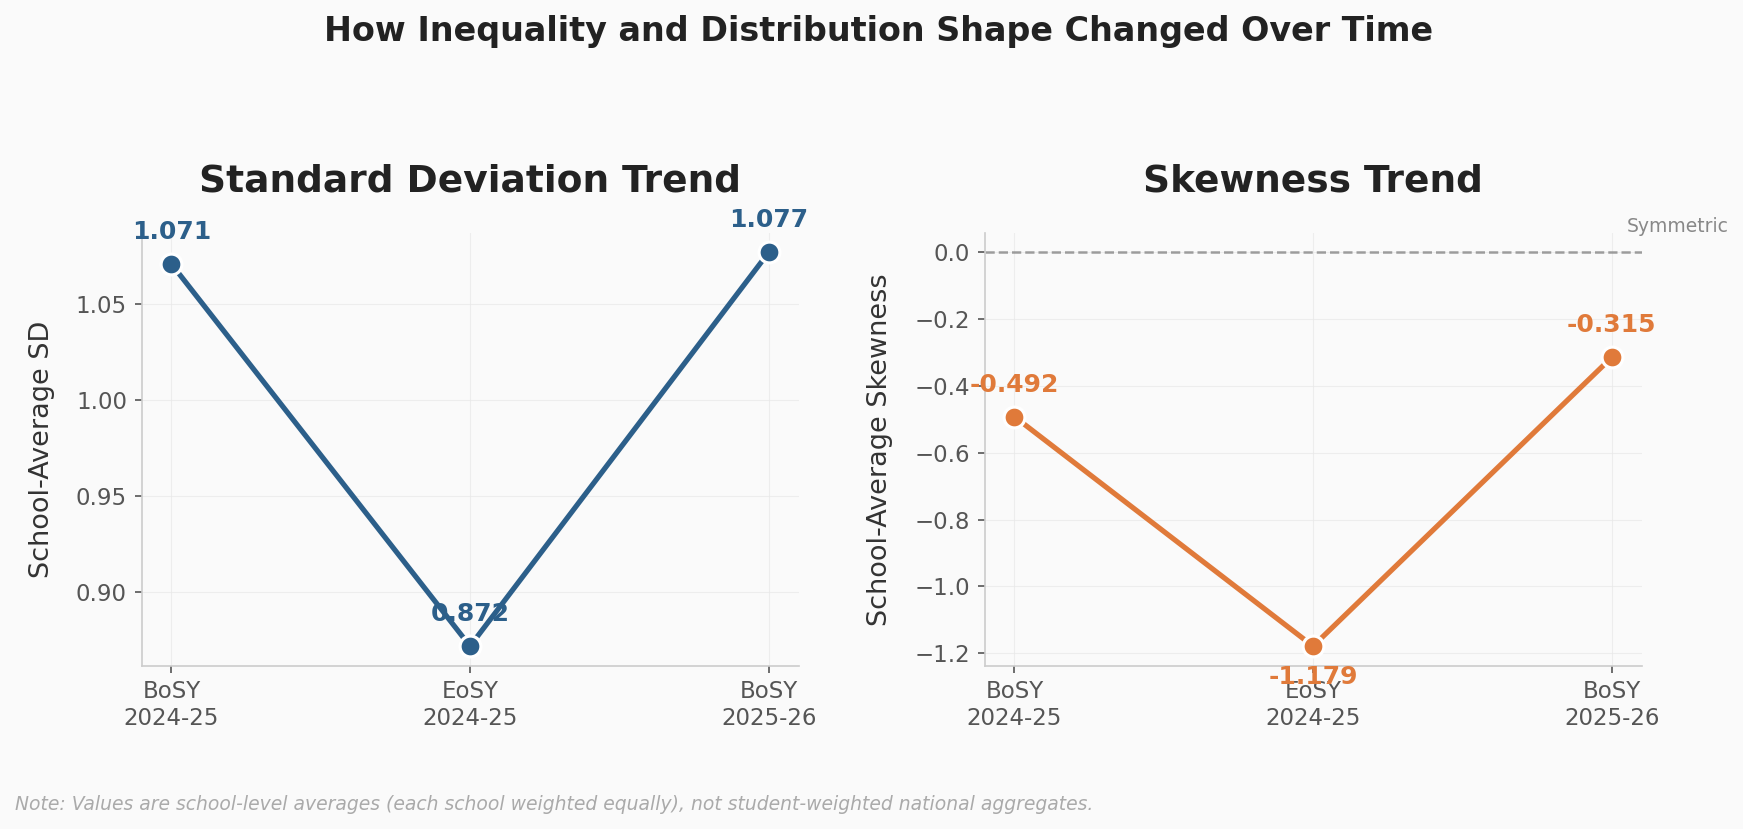

In [8]:
# ── Chart 6: National SD and Skewness Trends ──
# Compute school-average SD and skewness per timepoint from chain data
tp_cols_sd = {'BoSY 2024-25': 'sd_BoSY_2024-25', 'EoSY 2024-25': 'sd_EoSY_2024-25', 'BoSY 2025-26': 'sd_BoSY_2025-26'}
tp_cols_sk = {'BoSY 2024-25': 'skew_BoSY_2024-25', 'EoSY 2024-25': 'skew_EoSY_2024-25', 'BoSY 2025-26': 'skew_BoSY_2025-26'}

mean_sds = [chain[tp_cols_sd[t]].mean() for t in TIMEPOINTS]
mean_sks = [chain[tp_cols_sk[t]].mean() for t in TIMEPOINTS]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# SD trend
x_pos = [0, 1, 2]
ax1.plot(x_pos, mean_sds, 'o-', color=PAL['primary'], linewidth=2.5, markersize=10, markeredgecolor='white', markeredgewidth=1.5)
for i, v in enumerate(mean_sds):
    ax1.annotate(f'{v:.3f}', xy=(x_pos[i], v), xytext=(0, 12), textcoords='offset points',
                 fontsize=12, fontweight='bold', ha='center', color=PAL['primary'])
ax1.set_xticks(x_pos)
ax1.set_xticklabels([TP_SHORT[t] for t in TIMEPOINTS])
ax1.set_ylabel('School-Average SD')
ax1.set_title('Standard Deviation Trend')
clean_axes(ax1)

# Skewness trend
ax2.plot(x_pos, mean_sks, 'o-', color=PAL['secondary'], linewidth=2.5, markersize=10, markeredgecolor='white', markeredgewidth=1.5)
for i, v in enumerate(mean_sks):
    ax2.annotate(f'{v:.3f}', xy=(x_pos[i], v), xytext=(0, 12 if v > mean_sks[1] else -18), textcoords='offset points',
                 fontsize=12, fontweight='bold', ha='center', color=PAL['secondary'])
ax2.axhline(y=0, color='#888888', linewidth=1.2, linestyle='--', alpha=0.8)
ax2.text(2.05, 0.05, 'Symmetric', fontsize=9, color='#888888', va='bottom')
ax2.set_xticks(x_pos)
ax2.set_xticklabels([TP_SHORT[t] for t in TIMEPOINTS])
ax2.set_ylabel('School-Average Skewness')
ax2.set_title('Skewness Trend')
clean_axes(ax2)

fig.suptitle('How Inequality and Distribution Shape Changed Over Time', fontsize=16, fontweight='bold', y=1.02, color='#222222')

# Footnote
fig.text(0.02, -0.04, 'Note: Values are school-level averages (each school weighted equally), not student-weighted national aggregates.',
         fontsize=9, color='#AAAAAA', style='italic')

plt.tight_layout(pad=2.0)
plt.show()


---
## D. Which Schools Can We Reliably Rank?

> Not every school has enough data for a reliable ranking.
> We apply a series of data-quality filters to ensure only well-measured schools enter the priority list.


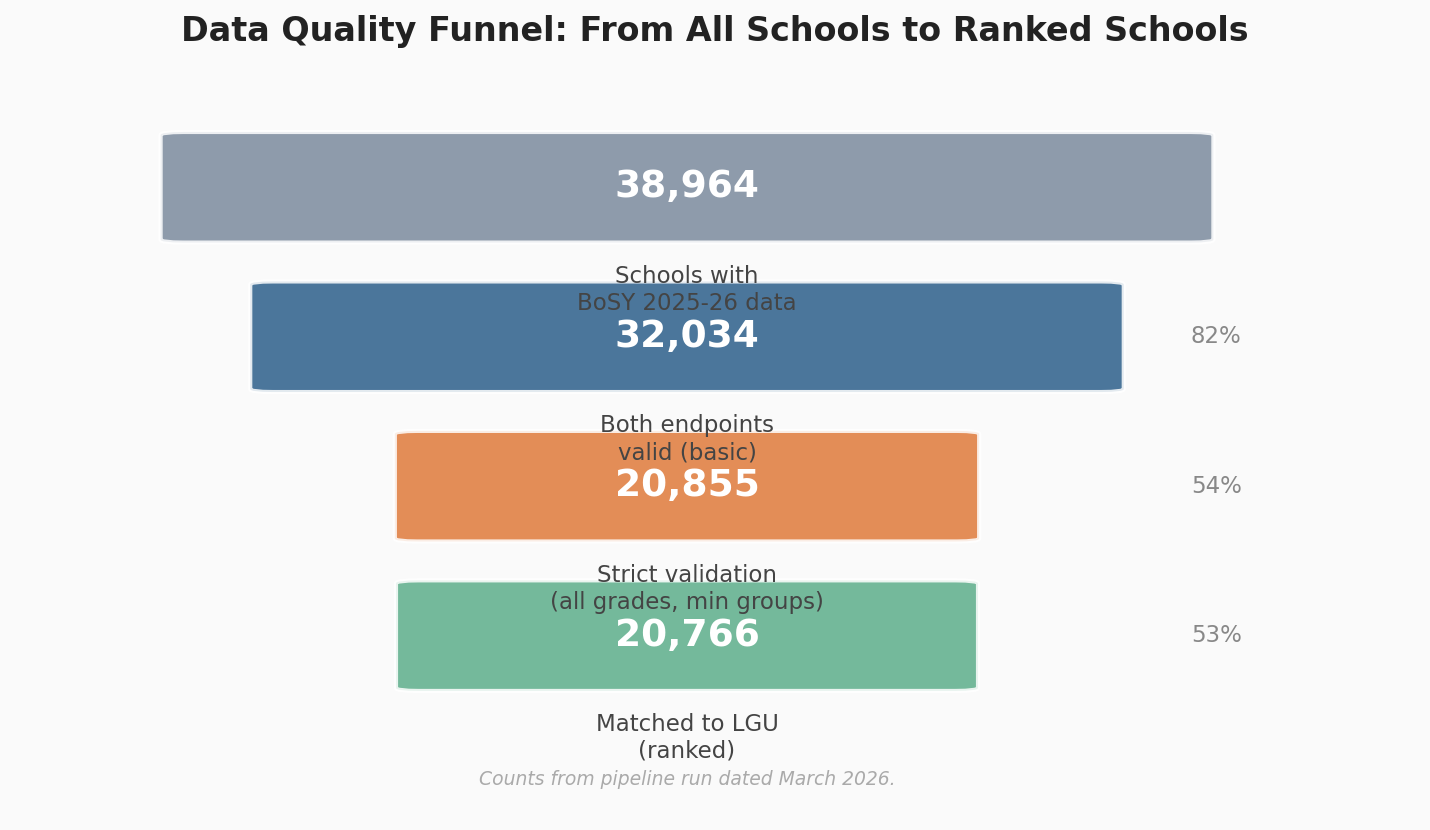

In [9]:
# ── Chart 7: Data Quality Funnel (computed from data) ──
# Compute counts from data
total_schools = chain['perf_BoSY_2025-26'].notna().sum()
seg2_valid_count = int(chain['seg2_valid'].sum())
ranked_count = len(ranking)

# Strict valid: schools that pass strict validation at BOTH endpoints
# Use ordinal parquet
eosy24_valid = set(schools[(schools['timepoint_label'] == 'EoSY 2024-25') & (schools['valid'] == True)]['School ID'])
bosy26_valid = set(schools[(schools['timepoint_label'] == 'BoSY 2025-26') & (schools['valid'] == True)]['School ID'])
strict_valid_count = len(eosy24_valid & bosy26_valid)

# Intermediate: ranked schools come from strict valid after LGU match
# lgu_dropped = strict_valid_count - ranked_count ... but strict_valid here is broader than pipeline's strict
# The pipeline's strict validation (all 3 grades, >=4 groups, >=15/group) is stricter
# ranked_count is computed dynamically from the CSV; LGU drop is from pipeline output
# Use: strict_valid_pipeline ≈ ranked + schools_without_lgu_match
# For display, we show what we can compute directly
strict_valid_pipeline = ranked_count + 89  # documented drop from LGU matching

stages = [
    ('Schools with\nBoSY 2025-26 data', total_schools),
    ('Both endpoints\nvalid (basic)', seg2_valid_count),
    ('Strict validation\n(all grades, min groups)', strict_valid_pipeline),
    ('Matched to LGU\n(ranked)', ranked_count),
]

fig, ax = plt.subplots(figsize=(10, 6))

max_w = 0.9
colors_funnel = [PAL['neutral'], PAL['primary'], PAL['secondary'], PAL['accent']]

for i, (label, count) in enumerate(stages):
    width = max_w * (count / stages[0][1])
    y = len(stages) - 1 - i
    left = (1 - width) / 2

    rect = FancyBboxPatch((left, y - 0.35), width, 0.7,
                           boxstyle="round,pad=0.02",
                           facecolor=colors_funnel[i], alpha=0.85,
                           edgecolor='white', linewidth=2)
    ax.add_patch(rect)

    ax.text(0.5, y, f'{count:,}', ha='center', va='center',
            fontsize=18, fontweight='bold', color='white')
    ax.text(0.5, y - 0.52, label, ha='center', va='top',
            fontsize=11, color='#444444')

    if i > 0:
        pct = count / stages[0][1] * 100
        ax.text(0.95, y, f'{pct:.0f}%', ha='left', va='center',
                fontsize=11, color='#888888')

ax.set_xlim(-0.1, 1.15)
ax.set_ylim(-1.2, len(stages) - 0.3)
ax.axis('off')
ax.set_title('Data Quality Funnel: From All Schools to Ranked Schools',
             fontsize=16, fontweight='bold', color='#222222', pad=20)

ax.text(0.5, -1.0, 'Counts from pipeline run dated March 2026.',
        ha='center', fontsize=9, color='#AAAAAA', style='italic')

plt.tight_layout(pad=2.0)
plt.show()


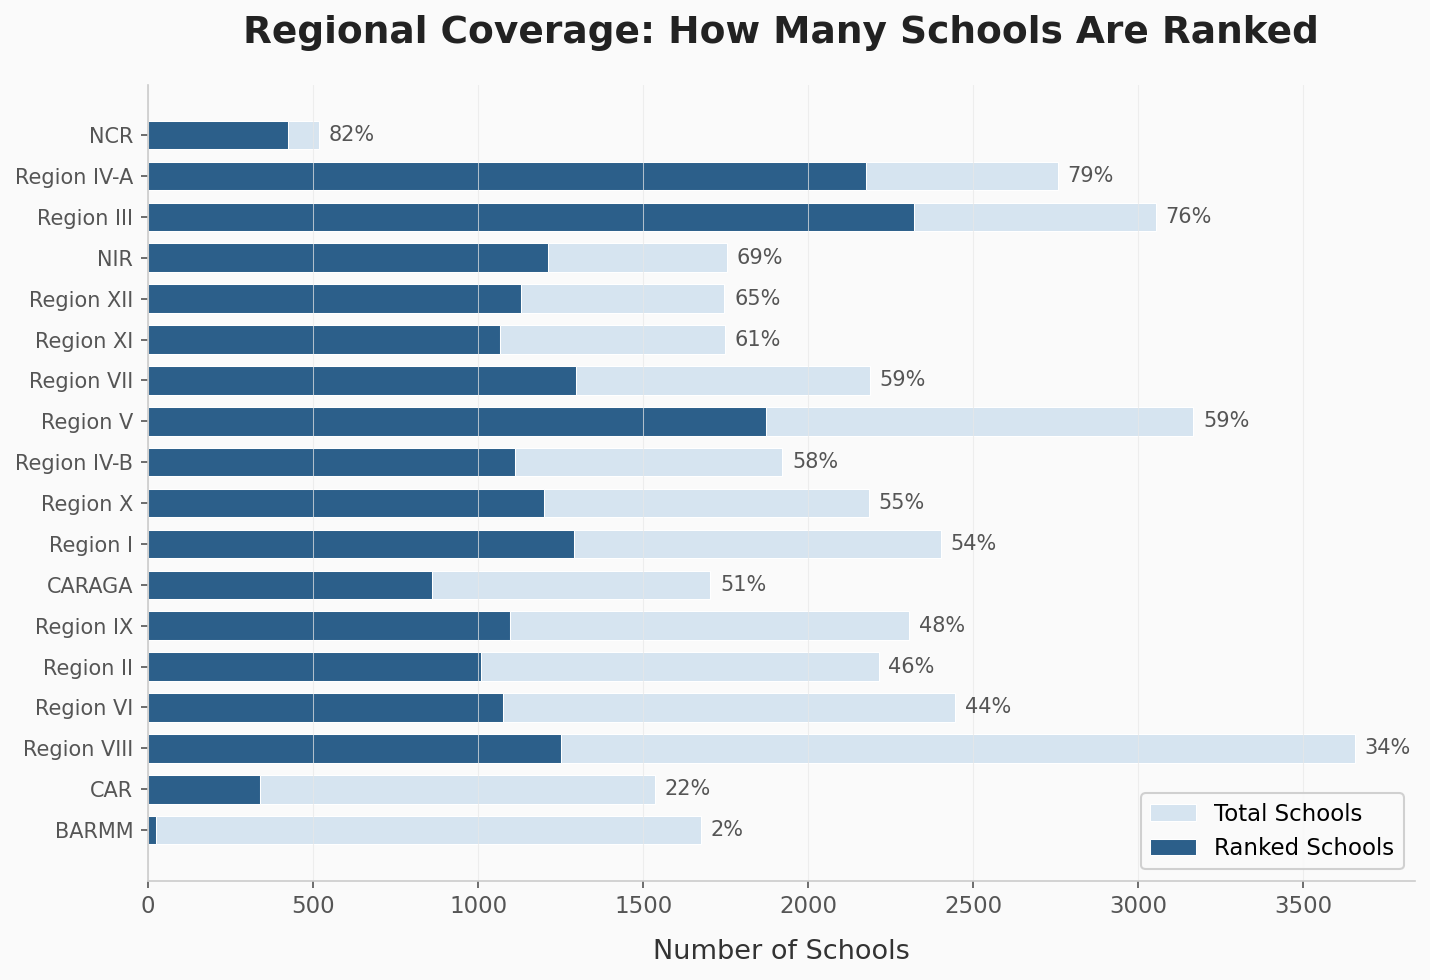

In [10]:
# ── Chart 8: Regional Coverage — Ranked vs Total Schools ──
# Total schools per region (from chain with BoSY 2025-26 data)
chain_valid = chain[chain['perf_BoSY_2025-26'].notna()]
total_by_region = chain_valid.groupby('Region')['School ID'].nunique().reset_index()
total_by_region.columns = ['Region', 'total']

# Ranked per region
ranked_by_region = ranking.groupby('region')['School ID'].nunique().reset_index()
ranked_by_region.columns = ['Region', 'ranked']

reg = total_by_region.merge(ranked_by_region, on='Region', how='left').fillna(0)
reg['ranked'] = reg['ranked'].astype(int)
reg['coverage'] = reg['ranked'] / reg['total'] * 100
reg = reg.sort_values('coverage', ascending=True)

fig, ax = plt.subplots(figsize=(10, 7))

y_pos = np.arange(len(reg))
ax.barh(y_pos, reg['total'].values, height=0.7, color='#D6E4F0', edgecolor='white', linewidth=0.5, label='Total Schools')
ax.barh(y_pos, reg['ranked'].values, height=0.7, color=PAL['primary'], edgecolor='white', linewidth=0.5, label='Ranked Schools')

for i, (tot, rnk, cov) in enumerate(zip(reg['total'], reg['ranked'], reg['coverage'])):
    ax.text(tot + 30, i, f'{cov:.0f}%', va='center', fontsize=10, color='#555555')

ax.set_yticks(y_pos)
ax.set_yticklabels(reg['Region'].values, fontsize=10)
ax.set_xlabel('Number of Schools')
ax.set_title('Regional Coverage: How Many Schools Are Ranked')
ax.legend(loc='lower right', frameon=True)
clean_axes(ax)
ax.grid(axis='y', visible=False)
plt.tight_layout(pad=2.0)
plt.show()


---
## E. Three Pillars of Priority

> The ranking combines three independent dimensions:
> 1. **Need** — how far behind is the school in reading proficiency, and how fast is it declining?
> 2. **Impact** — how many students would benefit from an intervention?
> 3. **Capacity Gap** — does the local government have the fiscal resources to help on its own?
>
> The final priority score is the product of percentile ranks across all three pillars — ensuring no single factor dominates.


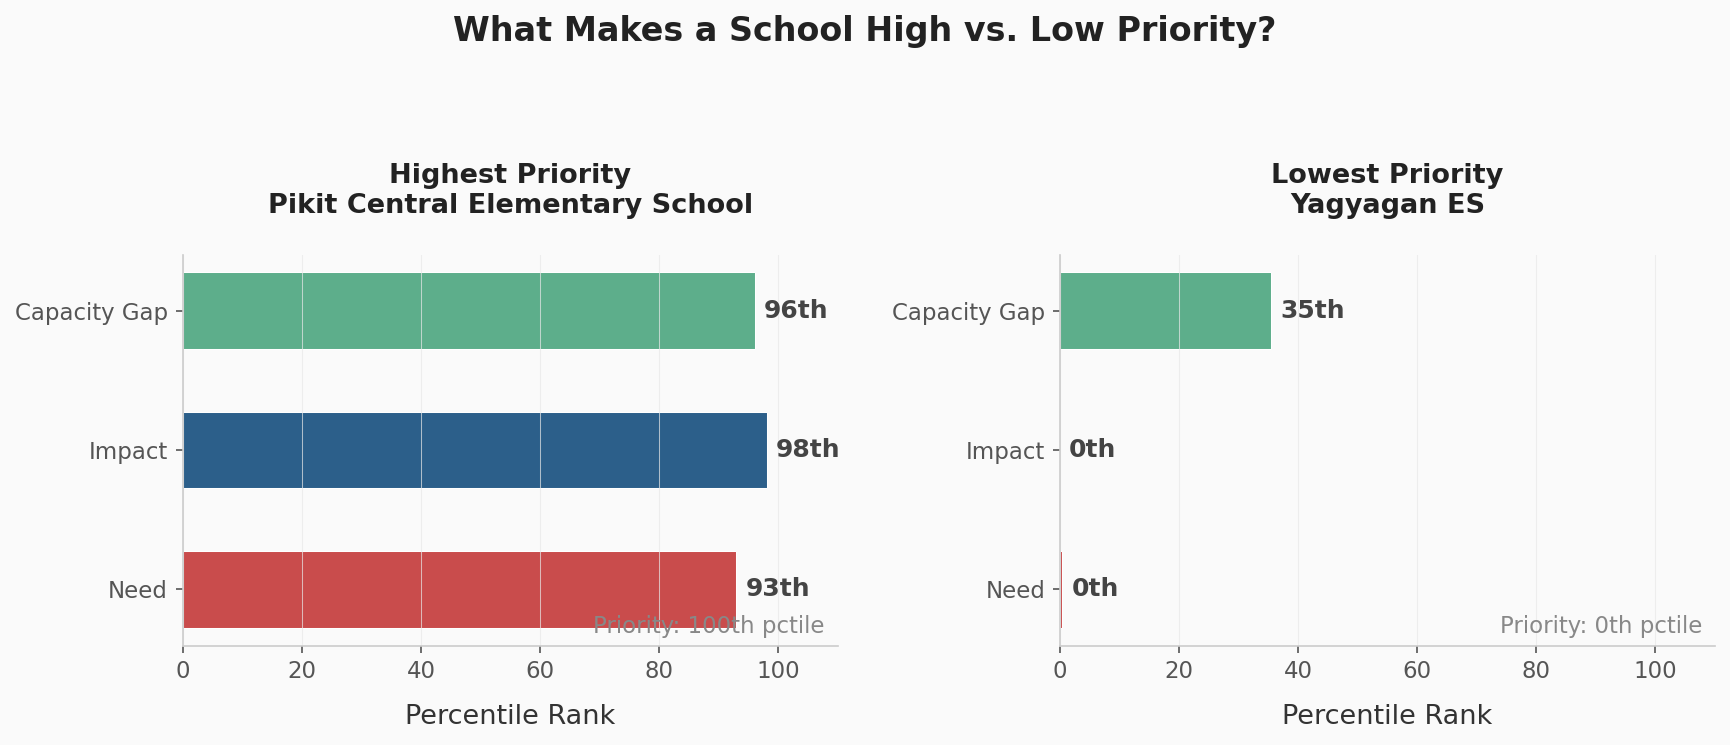

In [11]:
# ── Chart 9: Pillar Comparison — Highest vs Lowest Priority ──
top_school = ranking.nlargest(1, 'priority_pctile').iloc[0]
bot_school = ranking.nsmallest(1, 'priority_pctile').iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
pillars = ['Need', 'Impact', 'Capacity Gap']
pillar_cols = ['need_pctile', 'impact_pctile', 'capacity_gap_pctile']
pillar_colors = [PAL['warning'], PAL['primary'], PAL['accent']]

for idx, (school, ax, title_lbl) in enumerate(zip(
    [top_school, bot_school], axes, ['Highest Priority', 'Lowest Priority'])):

    vals = [school[c] * 100 for c in pillar_cols]
    bars = ax.barh(pillars, vals, color=pillar_colors, edgecolor='white', linewidth=0.5, height=0.55)

    for bar, v in zip(bars, vals):
        ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height()/2,
                f'{v:.0f}th', va='center', fontsize=12, fontweight='bold', color='#444444')

    ax.set_xlim(0, 110)
    ax.set_xlabel('Percentile Rank')
    ax.set_title(f'{title_lbl}\n{school["school_name"][:40]}', fontsize=13, fontweight='bold')
    ax.text(0.98, 0.02, f'Priority: {school["priority_pctile"]*100:.0f}th pctile',
            transform=ax.transAxes, ha='right', va='bottom', fontsize=11, color='#888888')
    clean_axes(ax)
    ax.grid(axis='y', visible=False)

fig.suptitle('What Makes a School High vs. Low Priority?', fontsize=16, fontweight='bold', y=1.02, color='#222222')
plt.tight_layout(pad=2.0)
plt.show()


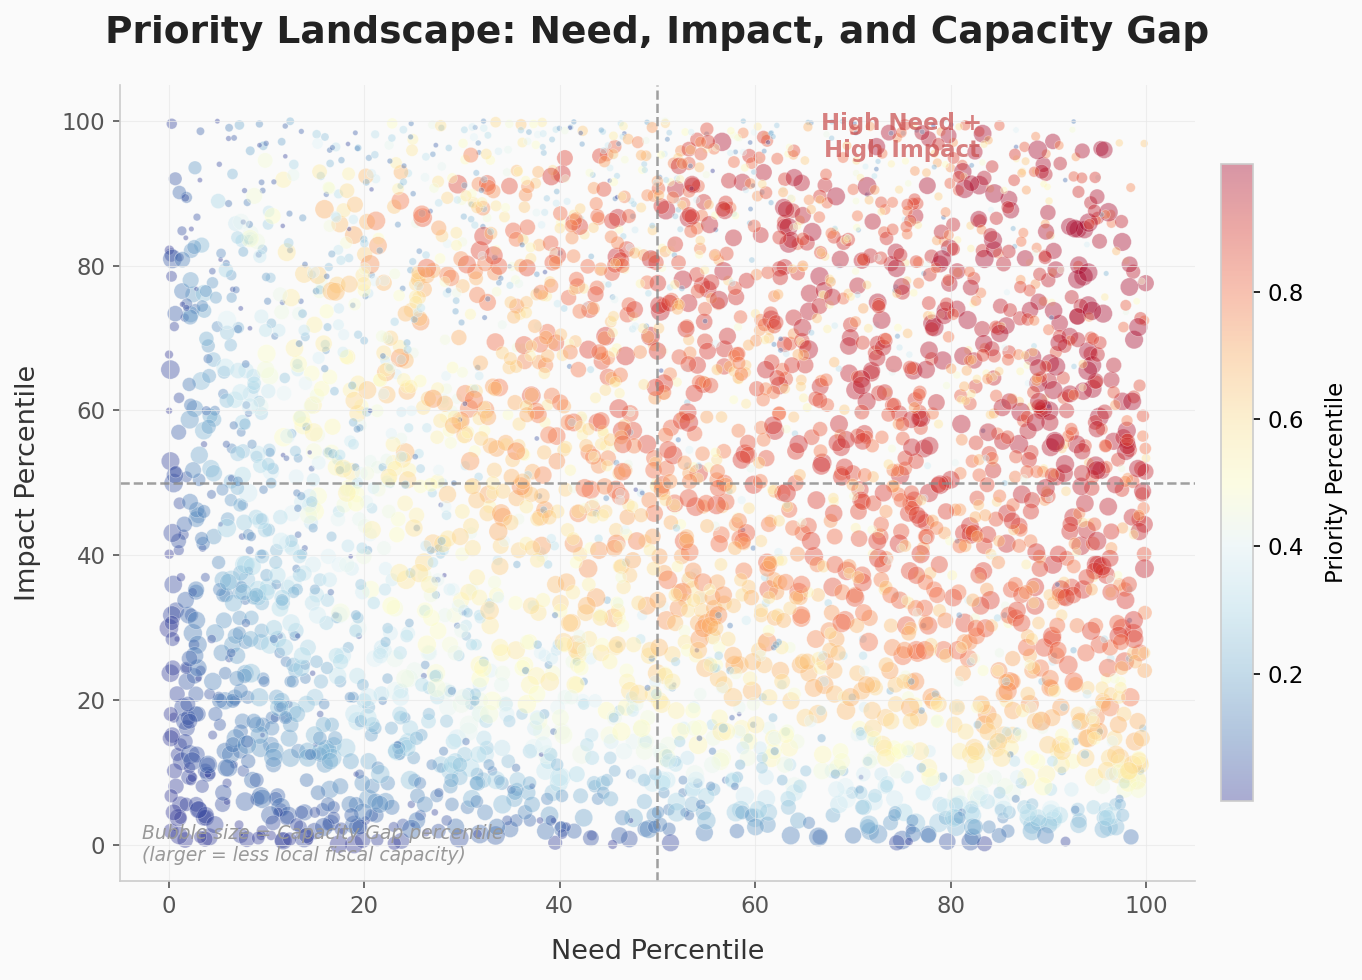

In [12]:
# ── Chart 10: Need × Impact × Capacity Gap (Bubble Scatter) ──
fig, ax = plt.subplots(figsize=(10, 7))

# Sample for readability if too many points
plot_data = ranking.copy()
if len(plot_data) > 4000:
    plot_data = plot_data.sample(4000, random_state=42)

# Bubble size = capacity gap percentile
sizes = plot_data['capacity_gap_pctile'] * 80 + 5

sc = ax.scatter(
    plot_data['need_pctile'] * 100,
    plot_data['impact_pctile'] * 100,
    s=sizes, alpha=0.4,
    c=plot_data['priority_pctile'],
    cmap='RdYlBu_r', edgecolors='white', linewidth=0.3
)

cbar = plt.colorbar(sc, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label('Priority Percentile', fontsize=11)

# Highlight top-right quadrant
ax.axhline(y=50, color='#888888', linewidth=1.2, linestyle='--', alpha=0.8)
ax.axvline(x=50, color='#888888', linewidth=1.2, linestyle='--', alpha=0.8)
ax.text(75, 95, 'High Need +\nHigh Impact', ha='center', fontsize=11, color='#C94C4C',
        fontweight='bold', alpha=0.7)

ax.set_xlabel('Need Percentile')
ax.set_ylabel('Impact Percentile')
ax.set_title('Priority Landscape: Need, Impact, and Capacity Gap')
ax.text(0.02, 0.02, 'Bubble size = Capacity Gap percentile\n(larger = less local fiscal capacity)',
        transform=ax.transAxes, fontsize=9, color='#999999', va='bottom', style='italic')
clean_axes(ax)
plt.tight_layout(pad=2.0)
plt.show()


---
## F. Is the Ranking Robust?

> A good ranking should be stable — it shouldn't change drastically if we slightly adjust the methodology.
> We test this in two ways:
> 1. **Scenario comparison** — do different weighting schemes produce similar rankings? (Kendall tau)
> 2. **Monte Carlo robustness** — if we randomly perturb the weights 500 times, how stable is each school's rank?


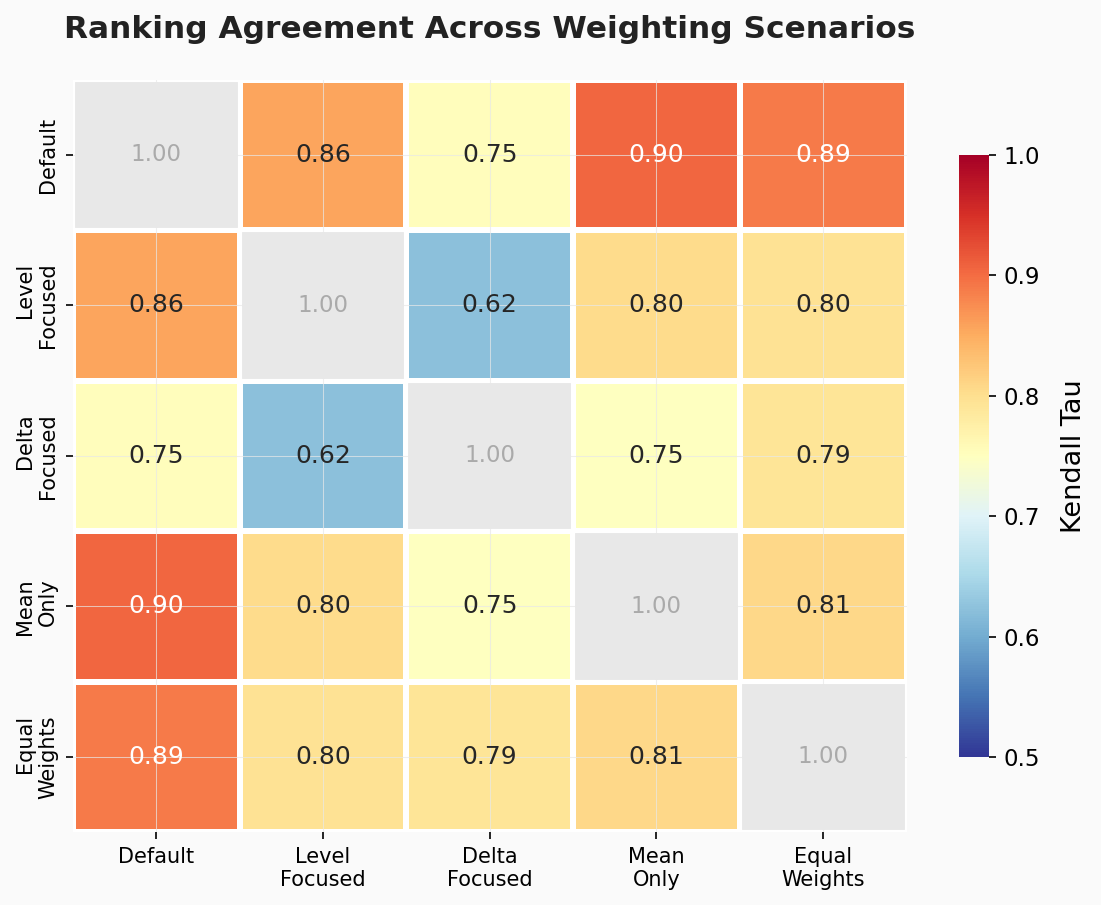

In [13]:
# ── Chart 11: Kendall Tau Heatmap (Scenario Comparison) ──
kt_matrix = ktau.set_index('Unnamed: 0')
kt_matrix.index.name = None

# Pretty labels
label_map = {'default': 'Default', 'level_focused': 'Level\nFocused', 'delta_focused': 'Delta\nFocused',
             'mean_only': 'Mean\nOnly', 'equal': 'Equal\nWeights'}
kt_matrix.index = [label_map.get(x, x) for x in kt_matrix.index]
kt_matrix.columns = [label_map.get(x, x) for x in kt_matrix.columns]

# Mask diagonal
mask_diag = np.eye(len(kt_matrix), dtype=bool)

fig, ax = plt.subplots(figsize=(8, 6.5))

sns.heatmap(kt_matrix.values, annot=True, fmt='.2f', cmap='RdYlBu_r',
            linewidths=2, linecolor='white',
            vmin=0.5, vmax=1.0,
            xticklabels=kt_matrix.columns, yticklabels=kt_matrix.index,
            ax=ax, cbar_kws={'label': 'Kendall Tau', 'shrink': 0.8},
            mask=mask_diag)

# Gray out diagonal cells
for i in range(len(kt_matrix)):
    ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=True, facecolor='#E8E8E8', edgecolor='white', linewidth=2))
    ax.text(i + 0.5, i + 0.5, '1.00', ha='center', va='center', fontsize=11, color='#AAAAAA')

ax.set_title('Ranking Agreement Across Weighting Scenarios', fontsize=15, fontweight='bold', color='#222222')
ax.tick_params(axis='both', labelsize=10)
plt.tight_layout(pad=2.0)
plt.show()


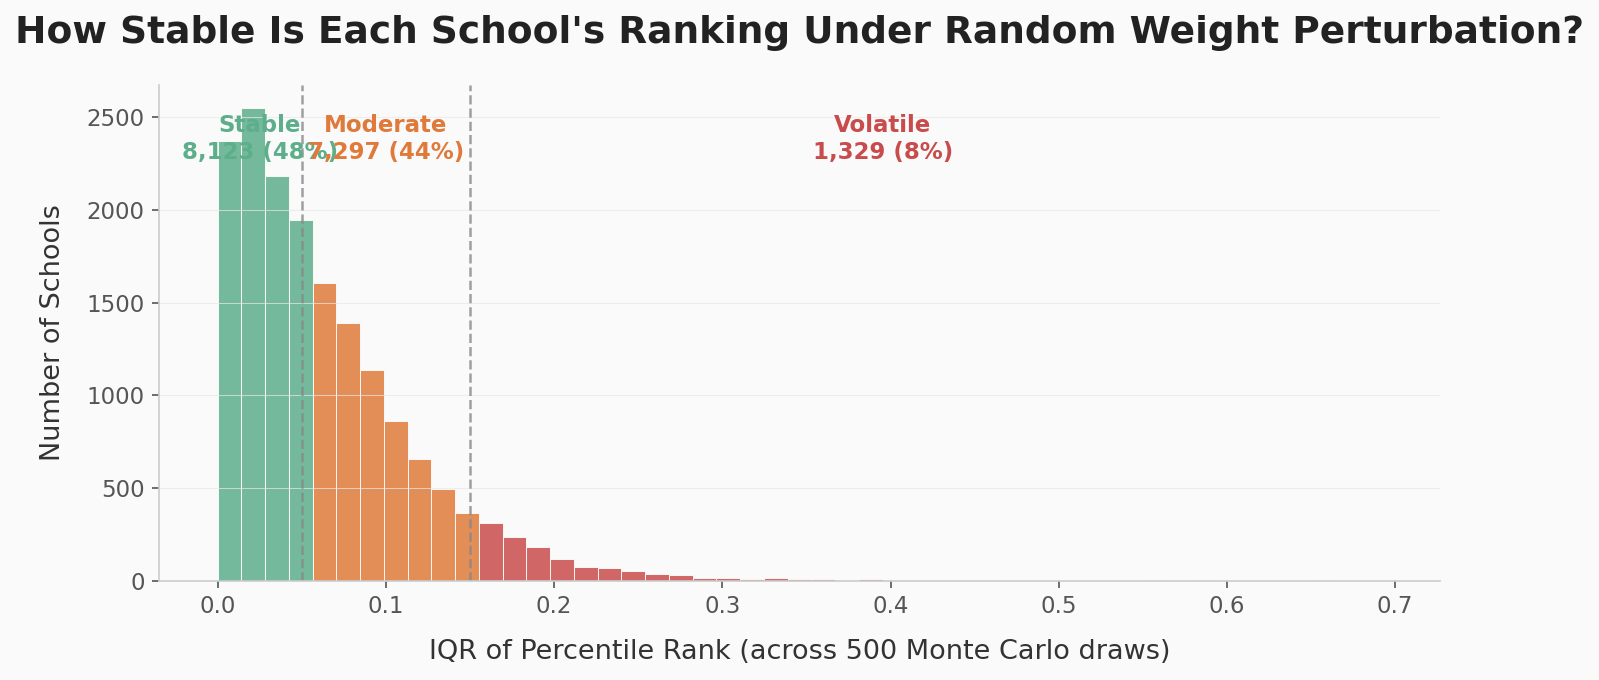

In [14]:
# ── Chart 12: Monte Carlo Stability — IQR Distribution ──
fig, ax = plt.subplots(figsize=(10, 5))

iqr = robust['iqr_pctile'].values

# Tiers
stable = (iqr < 0.05).sum()
moderate = ((iqr >= 0.05) & (iqr < 0.15)).sum()
volatile = (iqr >= 0.15).sum()
total = len(iqr)

# Histogram with tier coloring
bins = np.linspace(0, iqr.max() * 1.05, 50)
n, bin_edges, patches = ax.hist(iqr, bins=bins, edgecolor='white', linewidth=0.5, color=PAL['primary'], alpha=0.85)

# Color by tier
for patch, left_edge in zip(patches, bin_edges):
    if left_edge >= 0.15:
        patch.set_facecolor(PAL['warning'])
    elif left_edge >= 0.05:
        patch.set_facecolor(PAL['secondary'])
    else:
        patch.set_facecolor(PAL['accent'])

# Tier annotations
ax.axvline(x=0.05, color='#888888', linewidth=1.2, linestyle='--', alpha=0.8)
ax.axvline(x=0.15, color='#888888', linewidth=1.2, linestyle='--', alpha=0.8)

y_top = ax.get_ylim()[1]
ax.text(0.025, y_top * 0.85, f'Stable\n{stable:,} ({stable/total*100:.0f}%)',
        ha='center', fontsize=11, color=PAL['accent'], fontweight='bold')
ax.text(0.10, y_top * 0.85, f'Moderate\n{moderate:,} ({moderate/total*100:.0f}%)',
        ha='center', fontsize=11, color=PAL['secondary'], fontweight='bold')
ax.text(max(0.20, iqr.max()*0.6), y_top * 0.85, f'Volatile\n{volatile:,} ({volatile/total*100:.0f}%)',
        ha='center', fontsize=11, color=PAL['warning'], fontweight='bold')

ax.set_xlabel('IQR of Percentile Rank (across 500 Monte Carlo draws)')
ax.set_ylabel('Number of Schools')
ax.set_title('How Stable Is Each School\'s Ranking Under Random Weight Perturbation?')
clean_axes(ax)
ax.grid(axis='x', visible=False)
plt.tight_layout(pad=2.0)
plt.show()


---
## Summary

| Step | What We Do | Why It Matters |
|------|-----------|----------------|
| **Measure** | Compute mean, SD, and skewness of proficiency | Captures the full picture, not just averages |
| **Track** | Chain assessments across 3 timepoints | Identifies learning gains and summer loss |
| **Validate** | Apply strict data-quality filters | Ensures rankings are based on reliable data |
| **Rank** | Combine Need, Impact, and Capacity Gap | Prioritizes schools that need help most and have the fewest resources |
| **Stress-test** | Run 500+ robustness checks | Confirms rankings are stable, not artifacts of methodology choices |

> **Bottom line:** The priority ranking identifies schools with the greatest reading challenges, the most students to benefit, and the least local capacity to respond — and it does so robustly.

---
*CRLA Priority Ranking Framework — Department of Education, March 2026*
